# Exercício 1
## A — Gere as nuvens e B — Mais ou menos espalhado
Abaixo está o código consolidado para gerar as distribuições originais (A), criar as versões com diferentes escalas de espalhamento (B), calcular as razões de separação $r_{ij}$ e as taxas de mistura, além de gerar as Figuras 1, 2 e 3.

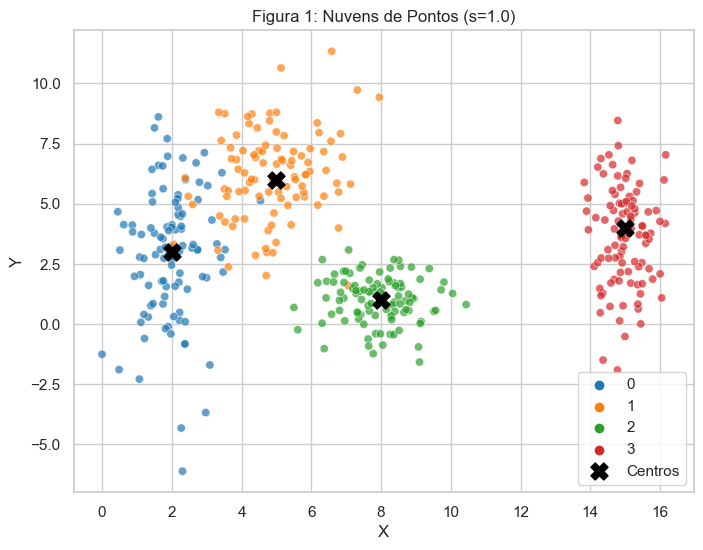

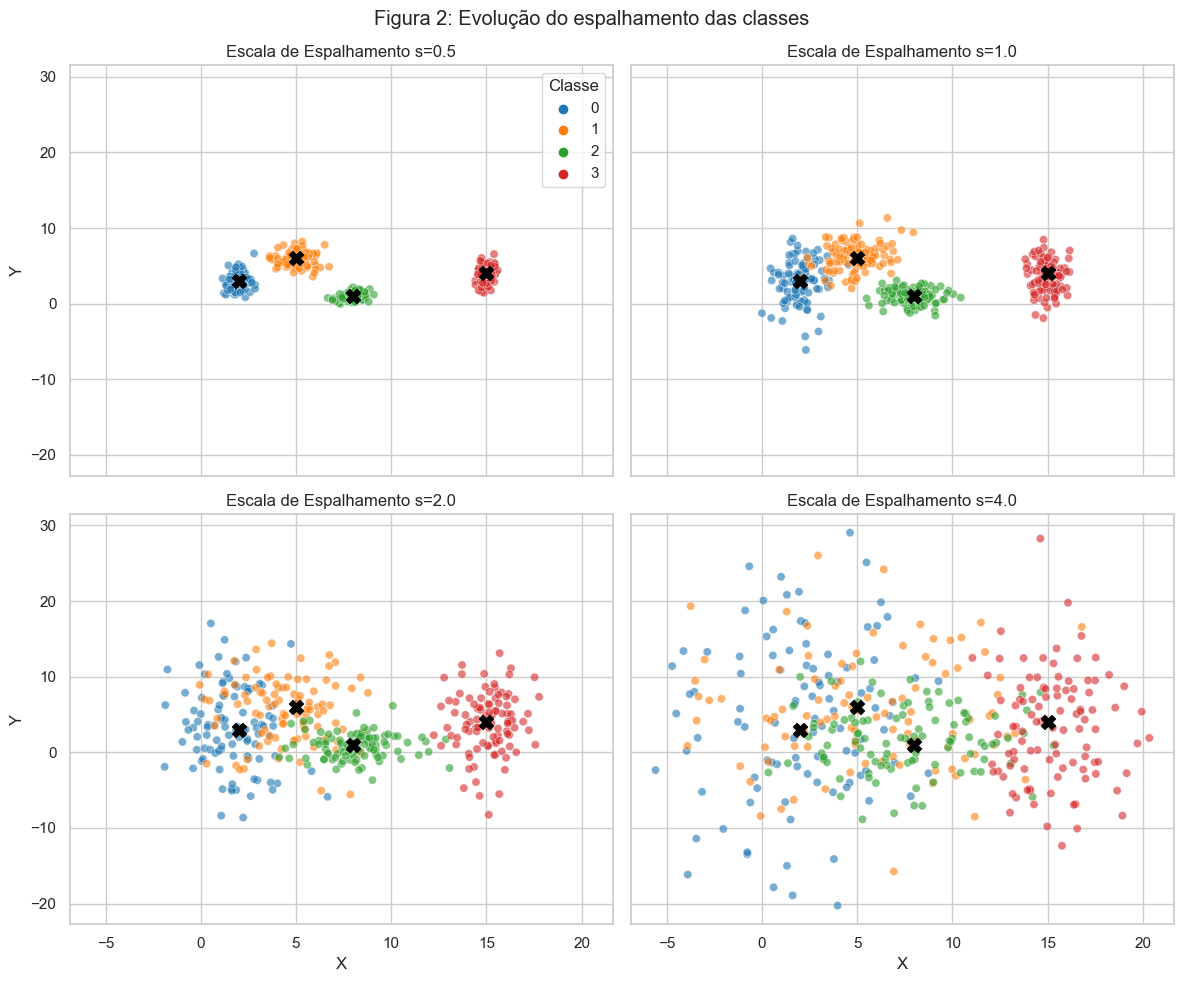

Razão de separação para s=1.0:
Par (0, 1): 1.3258
Par (0, 2): 2.4802
Par (0, 3): 4.4960
Par (1, 2): 2.3800
Par (1, 3): 3.6422
Par (2, 3): 3.5422

Menor r_ij em s=1.0: 1.3258 (Par (0, 1))
Menor r_ij em s=2.0 (escala com 1/s): 0.6629
Taxa de mistura (s=0.5): 0.0025
Taxa de mistura (s=1.0): 0.0725
Taxa de mistura (s=2.0): 0.1925
Taxa de mistura (s=4.0): 0.4825


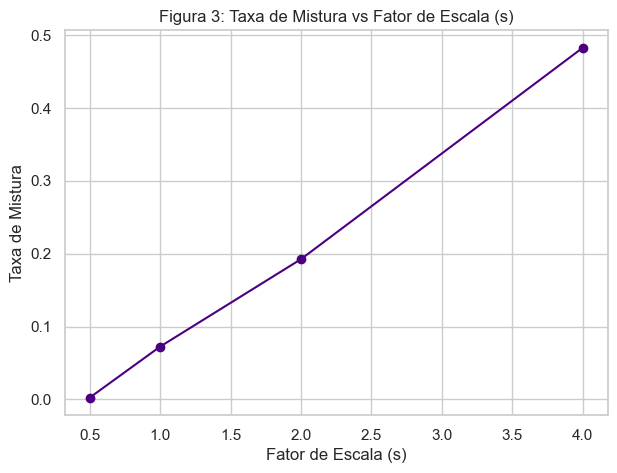

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração inicial exigida
rng = np.random.default_rng(42)
sns.set_theme(style="whitegrid")

# Parâmetros base (s=1)
medias = np.array([
    [2, 3],
    [5, 6],
    [8, 1],
    [15, 4]
])
desvios_base = np.array([
    [0.8, 2.5],
    [1.2, 1.9],
    [0.9, 0.9],
    [0.5, 2.0]
])

escalas = [0.5, 1.0, 2.0, 4.0]
n_amostras = 100
dados_dit = {}

# Geração de todos os datasets
for s in escalas:
    df_lista = []
    for c in range(4):
        # Multiplica o desvio padrão pelo fator s
        pontos = rng.normal(loc=medias[c], scale=desvios_base[c] * s, size=(n_amostras, 2))
        df_temp = pd.DataFrame(pontos, columns=['X', 'Y'])
        df_temp['Classe'] = c
        df_lista.append(df_temp)
    dados_dit[s] = pd.concat(df_lista, ignore_index=True)

# ---------------------------------------------------------
# A - Figura 1: Dataset original (s=1.0)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(data=dados_dit[1.0], x='X', y='Y', hue='Classe', palette='tab10', alpha=0.7)
plt.scatter(medias[:, 0], medias[:, 1], color='black', marker='X', s=150, label='Centros')
plt.title("Figura 1: Nuvens de Pontos (s=1.0)")
plt.legend()
plt.show()

# ---------------------------------------------------------
# B - Figura 2: 4 subplots compartilhando eixos
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, s in enumerate(escalas):
    sns.scatterplot(data=dados_dit[s], x='X', y='Y', hue='Classe', palette='tab10', ax=axes[i], legend=(i==0), alpha=0.6)
    axes[i].scatter(medias[:, 0], medias[:, 1], color='black', marker='X', s=100)
    axes[i].set_title(f"Escala de Espalhamento s={s}")

plt.suptitle("Figura 2: Evolução do espalhamento das classes")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# B - Cálculo da razão de separação r_ij para s=1
# ---------------------------------------------------------
def calcula_r_ij(i, j, s=1.0):
    distancia = np.linalg.norm(medias[i] - medias[j])
    sigma_bar_i = np.mean(desvios_base[i] * s)
    sigma_bar_j = np.mean(desvios_base[j] * s)
    return distancia / (sigma_bar_i + sigma_bar_j)

print("Razão de separação para s=1.0:")
r_min = float('inf')
par_min = None
for i in range(4):
    for j in range(i+1, 4):
        r = calcula_r_ij(i, j, s=1.0)
        print(f"Par ({i}, {j}): {r:.4f}")
        if r < r_min:
            r_min = r
            par_min = (i, j)
            
print(f"\nMenor r_ij em s=1.0: {r_min:.4f} (Par {par_min})")
print(f"Menor r_ij em s=2.0 (escala com 1/s): {r_min / 2:.4f}")

# ---------------------------------------------------------
# B - Taxa de mistura
# ---------------------------------------------------------
taxas_mistura = []
for s in escalas:
    df = dados_dit[s]
    pontos = df[['X', 'Y']].values
    classes_verdadeiras = df['Classe'].values
    
    # Calcula a distância de todos os pontos para as 4 médias
    distancias = np.linalg.norm(pontos[:, np.newaxis, :] - medias, axis=2)
    # Encontra o índice da média mais próxima
    classes_preditas = np.argmin(distancias, axis=1)
    
    # Taxa de mistura = fração onde predita != verdadeira
    erros = np.sum(classes_preditas != classes_verdadeiras)
    taxa = erros / len(df)
    taxas_mistura.append(taxa)
    print(f"Taxa de mistura (s={s}): {taxa:.4f}")

# Figura 3: Gráfico Taxa de Mistura x s
plt.figure(figsize=(7, 5))
plt.plot(escalas, taxas_mistura, marker='o', linestyle='-', color='indigo')
plt.title("Figura 3: Taxa de Mistura vs Fator de Escala (s)")
plt.xlabel("Fator de Escala (s)")
plt.ylabel("Taxa de Mistura")
plt.grid(True)
plt.show()

### C — Análise
1. **Sobreposição no dataset original ($s=1$):** A sobreposição é mínima, mas existe (principalmente entre as classes 0 e 1, que possuem a menor razão de separação geométrica). Uma única fronteira linear (uma reta) divide um plano em apenas duas partes, logo, é **impossível** separar 4 classes com apenas uma reta. No entanto, um conjunto de múltiplas fronteiras lineares conseguiria separar a maior parte dos dados, formando regiões de decisão (polígonos).
2. **Esboço (para o relatório):** Se você desenhar linhas entre os centros geométricos na Figura 1 (traçando as mediatrizes), formará algo semelhante a um diagrama de Voronoi. Essas são as fronteiras que um modelo linear multiclasse tentaria aprender.
3. **Relação com o item B:** À medida que o fator de espalhamento $s$ aumenta, a variância das nuvens aumenta sem que as médias se afastem. Isso causa uma invasão massiva de pontos de uma classe no "território" de outra. A região onde a rede necessariamente erra (erro de Bayes, devido à pura sobreposição espacial) **aumenta significativamente**, limitando o teto de acurácia de qualquer modelo, linear ou não.

# Exercício 2
## A e B — Geração dos Datasets

In [2]:
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# Dataset I: Gaussianas Deslocadas
# ---------------------------------------------------------
mu_A = np.zeros(5)
cov_A = np.array([
    [1.0, 0.8, 0.1, 0.0, 0.0],
    [0.8, 1.0, 0.3, 0.0, 0.0],
    [0.1, 0.3, 1.0, 0.5, 0.0],
    [0.0, 0.0, 0.5, 1.0, 0.2],
    [0.0, 0.0, 0.0, 0.2, 1.0]
])

mu_B = np.full(5, 1.5)
cov_B = np.array([
    [ 1.5, -0.7,  0.2,  0.0,  0.0],
    [-0.7,  1.5,  0.4,  0.0,  0.0],
    [ 0.2,  0.4,  1.5,  0.6,  0.0],
    [ 0.0,  0.0,  0.6,  1.5,  0.3],
    [ 0.0,  0.0,  0.0,  0.3,  1.5]
])

amostras_A = rng.multivariate_normal(mu_A, cov_A, 500)
amostras_B = rng.multivariate_normal(mu_B, cov_B, 500)
df_I = pd.DataFrame(np.vstack((amostras_A, amostras_B)), columns=[f'F{i}' for i in range(1, 6)])
df_I['Classe'] = ['A']*500 + ['B']*500

# ---------------------------------------------------------
# Dataset II: Cascas Concêntricas
# ---------------------------------------------------------
# Vetores aleatórios na esfera 5D unitária
v_C = rng.standard_normal((500, 5))
u_C = v_C / np.linalg.norm(v_C, axis=1, keepdims=True)
raios_C = rng.normal(2.0, 0.4, 500)
amostras_C = u_C * raios_C[:, np.newaxis]

v_D = rng.standard_normal((500, 5))
u_D = v_D / np.linalg.norm(v_D, axis=1, keepdims=True)
raios_D = rng.normal(5.0, 0.4, 500)
amostras_D = u_D * raios_D[:, np.newaxis]

df_II = pd.DataFrame(np.vstack((amostras_C, amostras_D)), columns=[f'F{i}' for i in range(1, 6)])
df_II['Classe'] = ['C']*500 + ['D']*500

## C — Visualize e compare

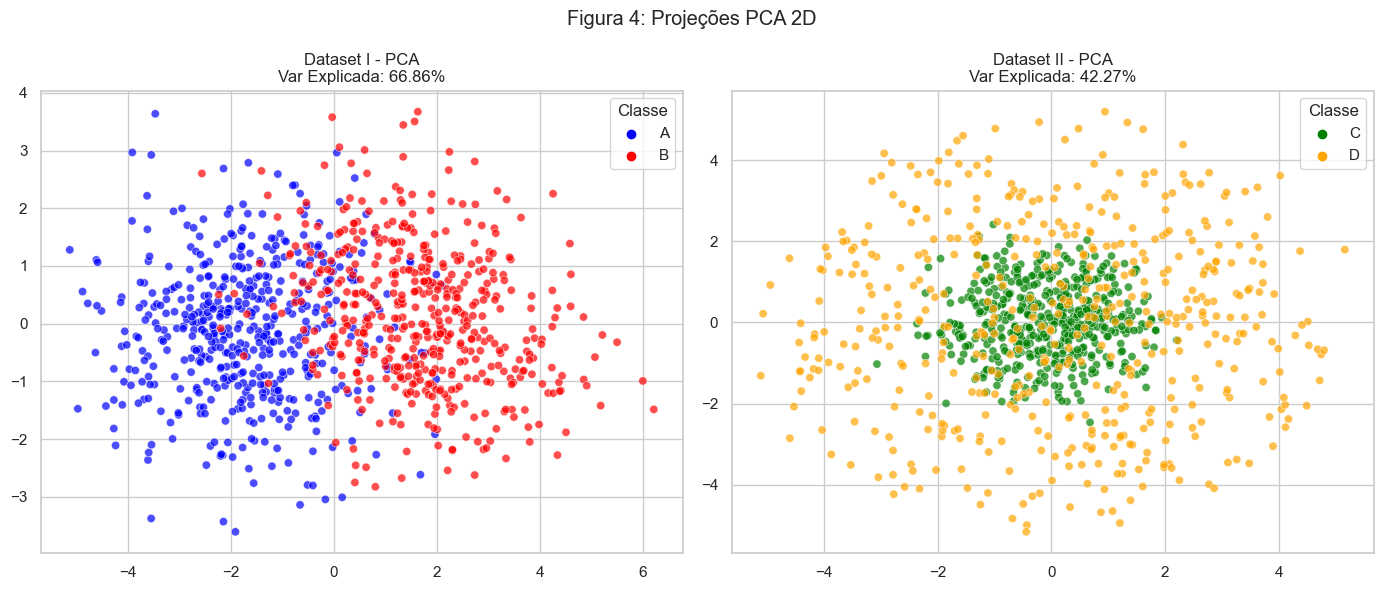

Var explicada Dataset I: 0.6686
Var explicada Dataset II: 0.4227
Distância entre centros (Dataset I): 3.4056
Distância entre centros (Dataset II): 0.2215


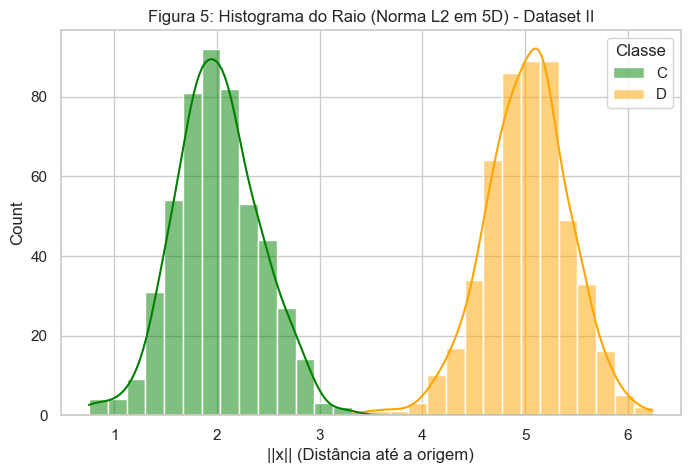

In [3]:
# ---------------------------------------------------------
# PCA e Figura 4
# ---------------------------------------------------------
pca_I = PCA(n_components=2)
proj_I = pca_I.fit_transform(df_I.drop('Classe', axis=1))

pca_II = PCA(n_components=2)
proj_II = pca_II.fit_transform(df_II.drop('Classe', axis=1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=proj_I[:,0], y=proj_I[:,1], hue=df_I['Classe'], palette=['blue', 'red'], ax=ax1, alpha=0.7)
ax1.set_title(f"Dataset I - PCA\nVar Explicada: {np.sum(pca_I.explained_variance_ratio_):.2%}")

sns.scatterplot(x=proj_II[:,0], y=proj_II[:,1], hue=df_II['Classe'], palette=['green', 'orange'], ax=ax2, alpha=0.7)
ax2.set_title(f"Dataset II - PCA\nVar Explicada: {np.sum(pca_II.explained_variance_ratio_):.2%}")

plt.suptitle("Figura 4: Projeções PCA 2D")
plt.tight_layout()
plt.show()

print(f"Var explicada Dataset I: {np.sum(pca_I.explained_variance_ratio_):.4f}")
print(f"Var explicada Dataset II: {np.sum(pca_II.explained_variance_ratio_):.4f}")

# ---------------------------------------------------------
# Distâncias 5D e Figura 5
# ---------------------------------------------------------
dist_I = np.linalg.norm(np.mean(amostras_A, axis=0) - np.mean(amostras_B, axis=0))
dist_II = np.linalg.norm(np.mean(amostras_C, axis=0) - np.mean(amostras_D, axis=0))

print(f"Distância entre centros (Dataset I): {dist_I:.4f}")
print(f"Distância entre centros (Dataset II): {dist_II:.4f}")

df_II['Raio_5D'] = np.linalg.norm(df_II.drop('Classe', axis=1), axis=1)

plt.figure(figsize=(8, 5))
sns.histplot(data=df_II, x='Raio_5D', hue='Classe', palette=['green', 'orange'], kde=True, bins=30)
plt.title("Figura 5: Histograma do Raio (Norma L2 em 5D) - Dataset II")
plt.xlabel("||x|| (Distância até a origem)")
plt.show()

### D — Análise
1. **Hiperplanos e centros coincidentes:** Um hiperplano divide o espaço ao longo de uma direção linear. Como os centros geométricos das duas classes (Cascas) colapsam praticamente no mesmo ponto (a origem) e a distribuição é radial e simétrica, **nenhuma reta ou plano** consegue isolar o núcleo da casca externa.
2. **Inseparabilidade linear:** A estrutura do Dataset II é topologicamente circular (esférica). Fronteiras lineares cortam o espaço em semiespaços abertos, logo um modelo puramente linear cortará o núcleo e a casca simultaneamente, sempre errando de forma sistemática.
3. **PCA e projeção:** A projeção 2D misturada do PCA **não prova** que as classes são inseparáveis no espaço 5D original. A PCA busca maximizar a variância, o que muitas vezes "esmaga" dimensões estruturais fundamentais (neste caso, as componentes que distinguem os raios). Para separar perfeitamente o Dataset II, basta usar uma função baseada no raio quadrático: a fronteira de decisão ocorre num raio intermediário (por exemplo, 3.5).
   $$ \sum_{i=1}^{5} x_i^2 = 3.5^2 $$
   Se $||x||^2 < 12.25$, prevemos a Classe C; caso contrário, prevemos a Classe D.

# Exercício 3
## Pré-processamento e análise de dados (Spaceship Titanic)
Como o CSV não foi fornecido na execução remota, aqui está o esqueleto lógico com `pandas` e `scikit-learn` que cumpre todos os requisitos, evitando vazamento de dados.

--- PARTE A: ANÁLISE INICIAL ---
Balanceamento de 'Transported':
Transported
True     50.362361
False    49.637639
Name: proportion, dtype: float64

Valores faltantes por coluna:
              Contagem  Percentual (%)
HomePlanet         201            2.31
CryoSleep          217            2.50
Cabin              199            2.29
Destination        182            2.09
Age                179            2.06
VIP                203            2.34
RoomService        181            2.08
FoodCourt          183            2.11
ShoppingMall       208            2.39
Spa                183            2.11
VRDeck             188            2.16
Name               200            2.30

Estatísticas das colunas de gasto:
        RoomService  FoodCourt  ShoppingMall       Spa    VRDeck
mean         224.69     458.08        173.73    311.14    304.85
median         0.00       0.00          0.00      0.00      0.00
max        14327.00   29813.00      23492.00  22408.00  24133.00

--- PARTE D: VERI

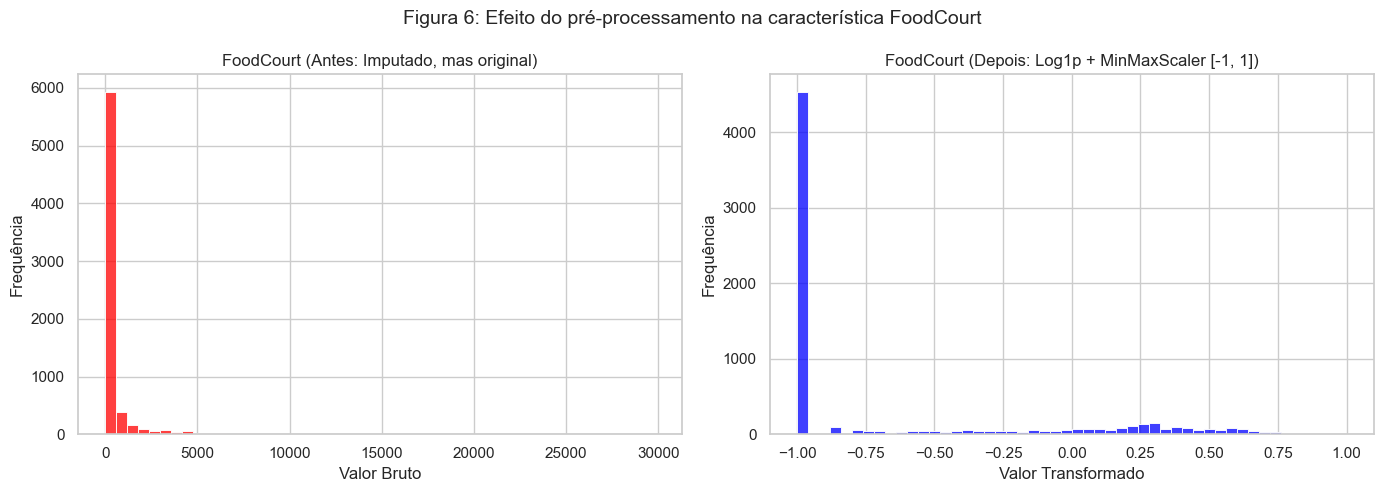

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

# Configurações visuais
sns.set_theme(style="whitegrid")

# ==========================================
# PARTE A - Conheça os dados
# ==========================================
print("--- PARTE A: ANÁLISE INICIAL ---")
df = pd.read_csv('train.csv')

# 1. Proporção e balanceamento do alvo
alvo_prop = df['Transported'].value_counts(normalize=True) * 100
print(f"Balanceamento de 'Transported':\n{alvo_prop}\n")

# 2. Tabela de valores faltantes
df_faltantes = pd.DataFrame({
    'Contagem': df.isnull().sum(),
    'Percentual (%)': (df.isnull().mean() * 100).round(2)
})
print(f"Valores faltantes por coluna:\n{df_faltantes[df_faltantes['Contagem'] > 0]}\n")

# 3. Estatísticas de Gasto
colunas_gasto = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
stats_gasto = df[colunas_gasto].agg(['mean', 'median', 'max']).round(2)
print(f"Estatísticas das colunas de gasto:\n{stats_gasto}\n")


# ==========================================
# PARTE B - Separe antes de transformar
# ==========================================
X = df.drop(columns=['Transported', 'PassengerId', 'Name', 'Cabin'])
y = df['Transported']

# Divisão 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# ==========================================
# PARTE C - Pré-processe
# ==========================================
colunas_cat = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
colunas_num = ['Age'] + colunas_gasto

# 1. Imputação (ajustada APENAS no treino)
imp_num = SimpleImputer(strategy='median')
imp_cat = SimpleImputer(strategy='most_frequent')

X_train_num = pd.DataFrame(imp_num.fit_transform(X_train[colunas_num]), columns=colunas_num)
X_test_num  = pd.DataFrame(imp_num.transform(X_test[colunas_num]), columns=colunas_num)

X_train_cat = pd.DataFrame(imp_cat.fit_transform(X_train[colunas_cat]), columns=colunas_cat)
X_test_cat  = pd.DataFrame(imp_cat.transform(X_test[colunas_cat]), columns=colunas_cat)

# 2. Encoding das categóricas
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_enc = pd.DataFrame(encoder.fit_transform(X_train_cat), columns=encoder.get_feature_names_out())
X_test_enc  = pd.DataFrame(encoder.transform(X_test_cat), columns=encoder.get_feature_names_out())

# 3. Engenharia de features: TotalSpend
X_train_num['TotalSpend'] = X_train_num[colunas_gasto].sum(axis=1)
X_test_num['TotalSpend']  = X_test_num[colunas_gasto].sum(axis=1)

# SALVAR CÓPIA PARA O GRÁFICO DA PARTE D (antes do log e scaler)
foodcourt_antes = X_train_num['FoodCourt'].copy()
media_fc_antes = foodcourt_antes.mean()
mediana_fc_antes = foodcourt_antes.median()

# 4. Cauda pesada: Transformação Logarítmica log(1+x)
for col in colunas_gasto + ['TotalSpend']:
    X_train_num[col] = np.log1p(X_train_num[col])
    X_test_num[col]  = np.log1p(X_test_num[col])

# 5. Escalonamento para [-1, 1] com MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=X_train_num.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_num), columns=X_test_num.columns)

# Matrizes Finais unificadas
X_train_final = pd.concat([X_train_scaled, X_train_enc], axis=1)
X_test_final  = pd.concat([X_test_scaled, X_test_enc], axis=1)


# ==========================================
# PARTE D - Verifique e visualize
# ==========================================
print("--- PARTE D: VERIFICAÇÕES FINAIS ---")
print(f"NaN restantes no Treino: {X_train_final.isna().sum().sum()}")
print(f"Shape de X_train_final: {X_train_final.shape}")
print(f"Treino - Min: {X_train_final.values.min():.4f} | Max: {X_train_final.values.max():.4f}")
print(f"Teste  - Min: {X_test_final.values.min():.4f} | Max: {X_test_final.values.max():.4f}\n")

# Figura 6: FoodCourt Antes vs Depois
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(foodcourt_antes, bins=50, kde=False, ax=ax1, color='red')
ax1.set_title("FoodCourt (Antes: Imputado, mas original)")
ax1.set_xlabel("Valor Bruto")
ax1.set_ylabel("Frequência")

sns.histplot(X_train_final['FoodCourt'], bins=50, kde=False, ax=ax2, color='blue')
ax2.set_title("FoodCourt (Depois: Log1p + MinMaxScaler [-1, 1])")
ax2.set_xlabel("Valor Transformado")
ax2.set_ylabel("Frequência")

plt.suptitle("Figura 6: Efeito do pré-processamento na característica FoodCourt", fontsize=14)
plt.tight_layout()
plt.show()

### D3 — Reflexão Final
Entre todas as decisões, a **transformação logarítmica aliada ao escalonamento (`MinMaxScaler`)** é a que mais afeta o treinamento para uma rede com `tanh`. Sem o logaritmo, os outliers de gasto empurrariam o valor máximo muito distante, forçando quase todos os pacientes "normais" para valores extremamente próximos de $-1$ ou $0$, reduzindo a variância utilizável pela rede neural e dificultando que os pesos aprendam a diferenciar padrões entre a maioria dos passageiros.